# Exercice Semaine 2 — Impact de la Maturité et de la Volatilité sur l'Estimateur Monte-Carlo

L'objectif est de comprendre comment les paramètres **T (maturité)** et **σ (volatilité)** influencent la **précision** de l'estimateur Monte-Carlo du prix d'un call européen.

La précision est mesurée via la **variance de l'estimateur**, directement liée à la largeur de l'intervalle de confiance :
$$\text{IC}_{95\%} = \hat{P} \pm 1.96 \cdot \frac{\hat{\sigma}_{\text{payoff}}}{\sqrt{N}}$$

## Fonctions utilitaires

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import norm

plt.style.use('seaborn-v0_8-darkgrid')

def brownien(T, n, nb_trajectoires=1, seed=None):
    """Simule des trajectoires de mouvement brownien standard."""
    if seed is not None:
        np.random.seed(seed)
    dt = T / n
    t = np.linspace(0, T, n + 1)
    dW = np.sqrt(dt) * np.random.randn(n, nb_trajectoires)
    W = np.zeros((n + 1, nb_trajectoires))
    W[1:, :] = np.cumsum(dW, axis=0)
    return t, W


def monte_carlo_call(S0, K, r, sigma, T, N=50000, seed=None):
    """
    Valorise un call européen par Monte-Carlo et retourne :
      - prix estimé
      - variance des payoffs actualisés
      - demi-largeur de l'IC à 95%
    """
    _, W = brownien(T, 1, nb_trajectoires=N, seed=seed)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * W[-1, :])
    payoff = np.exp(-r * T) * np.maximum(S_T - K, 0)
    prix = np.mean(payoff)
    variance = np.var(payoff, ddof=1)
    ic = 1.96 * np.sqrt(variance / N)
    return prix, variance, ic


def black_scholes_call(S0, K, r, sigma, T):
    """Prix exact du call européen par la formule de Black-Scholes."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

---
## Partie 1 — Impact de la Maturité T

On fixe σ et on fait varier T.

In [11]:
# Paramètres fixes
S0    = 100
K     = 100
r     = 0.05
sigma = 0.2
N     = 50000

maturites = np.array([0.1, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0])

resultats_T = []
for T in maturites:
    prix, var, ic = monte_carlo_call(S0, K, r, sigma, T, N=N, seed=42)
    prix_bs = black_scholes_call(S0, K, r, sigma, T)
    resultats_T.append((T, prix, var, ic, prix_bs))

resultats_T = np.array(resultats_T)

print(f"{'T':>6}  {'Prix MC':>10}  {'Prix BS':>10}  {'Variance':>12}  {'IC (±)':>10}")
print("-" * 58)
for row in resultats_T:
    print(f"{row[0]:>6.2f}  {row[1]:>10.4f}  {row[4]:>10.4f}  {row[2]:>12.6f}  {row[3]:>10.6f}")

     T     Prix MC     Prix BS      Variance      IC (±)
----------------------------------------------------------
  0.10      2.7725      2.7737     15.946787    0.035003
  0.25      4.6130      4.6150     43.477389    0.057797
  0.50      6.8859      6.8887     95.400546    0.085614
  1.00     10.4462     10.4506    215.682018    0.128729
  2.00     16.1192     16.1268    504.997517    0.196977
  3.00     20.9133     20.9244    845.313791    0.254847
  5.00     29.1178     29.1386   1648.182488    0.355856


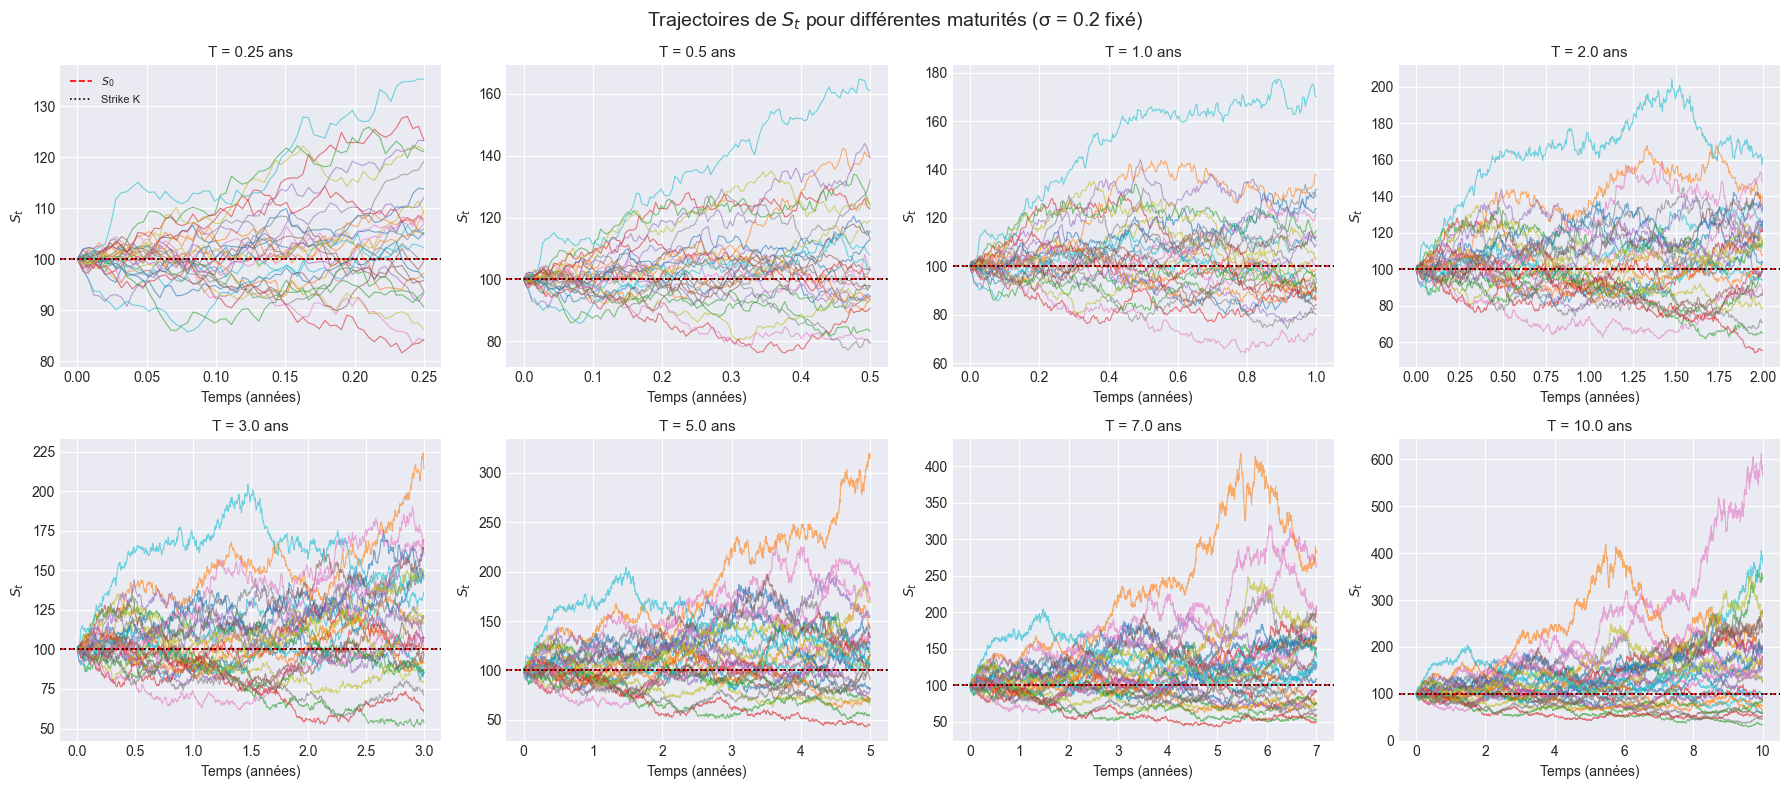

In [12]:
# Visualisation des trajectoires de S_T pour différentes maturités
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Trajectoires de $S_t$ pour différentes maturités (σ = 0.2 fixé)", fontsize=14)

maturites_viz = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
nb_traj_viz = 30

for idx, T in enumerate(maturites_viz):
    ax = axes[idx // 4, idx % 4]
    n = int(252 * T)  # ~252 pas par an
    t, W = brownien(T, n, nb_trajectoires=nb_traj_viz, seed=42)
    S = S0 * np.exp((r - 0.5 * sigma**2) * t[:, np.newaxis] + sigma * W)

    for i in range(nb_traj_viz):
        ax.plot(t, S[:, i], linewidth=0.8, alpha=0.6)

    ax.axhline(y=S0, color='red', linestyle='--', linewidth=1.2, label='$S_0$')
    ax.axhline(y=K, color='black', linestyle=':', linewidth=1.2, label='Strike K')
    ax.set_title(f"T = {T} ans", fontsize=11)
    ax.set_xlabel("Temps (années)")
    ax.set_ylabel("$S_t$")
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

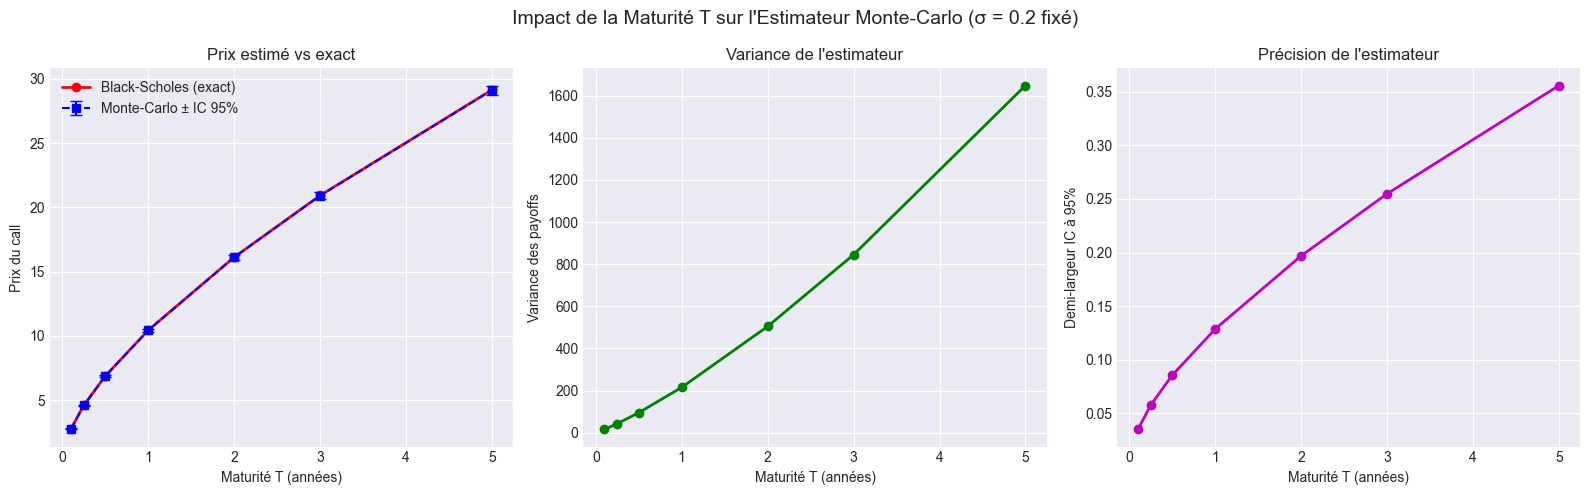

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact de la Maturité T sur l'Estimateur Monte-Carlo (σ = 0.2 fixé)", fontsize=14)

T_vals     = resultats_T[:, 0]
prix_mc    = resultats_T[:, 1]
variances  = resultats_T[:, 2]
ic_vals    = resultats_T[:, 3]
prix_bs    = resultats_T[:, 4]

# --- Graphe 1 : Prix MC vs BS ---
axes[0].plot(T_vals, prix_bs, 'r-o', label='Black-Scholes (exact)', linewidth=2)
axes[0].errorbar(T_vals, prix_mc, yerr=ic_vals, fmt='b--s',
                 label='Monte-Carlo ± IC 95%', linewidth=1.5, capsize=4)
axes[0].set_xlabel('Maturité T (années)')
axes[0].set_ylabel('Prix du call')
axes[0].set_title('Prix estimé vs exact')
axes[0].legend()

# --- Graphe 2 : Variance ---
axes[1].plot(T_vals, variances, 'g-o', linewidth=2)
axes[1].set_xlabel('Maturité T (années)')
axes[1].set_ylabel('Variance des payoffs')
axes[1].set_title('Variance de l\'estimateur')

# --- Graphe 3 : Largeur IC ---
axes[2].plot(T_vals, ic_vals, 'm-o', linewidth=2)
axes[2].set_xlabel('Maturité T (années)')
axes[2].set_ylabel('Demi-largeur IC à 95%')
axes[2].set_title('Précision de l\'estimateur')

plt.tight_layout()
plt.show()

**Observation :** Plus T est grand, plus les trajectoires de $S_T$ sont dispersées, ce qui fait croître la variance du payoff et élargit l'intervalle de confiance.

---
## Partie 2 — Impact de la Volatilité σ

On fixe T et on fait varier σ.

In [14]:
T_fixe = 1.0
volatilites = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70])

resultats_sigma = []
for sigma in volatilites:
    prix, var, ic = monte_carlo_call(S0, K, r, sigma, T_fixe, N=N, seed=42)
    prix_bs = black_scholes_call(S0, K, r, sigma, T_fixe)
    resultats_sigma.append((sigma, prix, var, ic, prix_bs))

resultats_sigma = np.array(resultats_sigma)

print(f"{'σ':>6}  {'Prix MC':>10}  {'Prix BS':>10}  {'Variance':>12}  {'IC (±)':>10}")
print("-" * 58)
for row in resultats_sigma:
    print(f"{row[0]:>6.2f}  {row[1]:>10.4f}  {row[4]:>10.4f}  {row[2]:>12.6f}  {row[3]:>10.6f}")

     σ     Prix MC     Prix BS      Variance      IC (±)
----------------------------------------------------------
  0.05      5.2816      5.2833     19.186555    0.038395
  0.10      6.8046      6.8050     59.641161    0.067693
  0.20     10.4462     10.4506    215.682018    0.128729
  0.30     14.2190     14.2313    503.915257    0.196766
  0.40     18.0011     18.0230    970.912494    0.273125
  0.50     21.7588     21.7926   1678.185016    0.359080
  0.70     29.1347     29.2027   4173.493978    0.566267


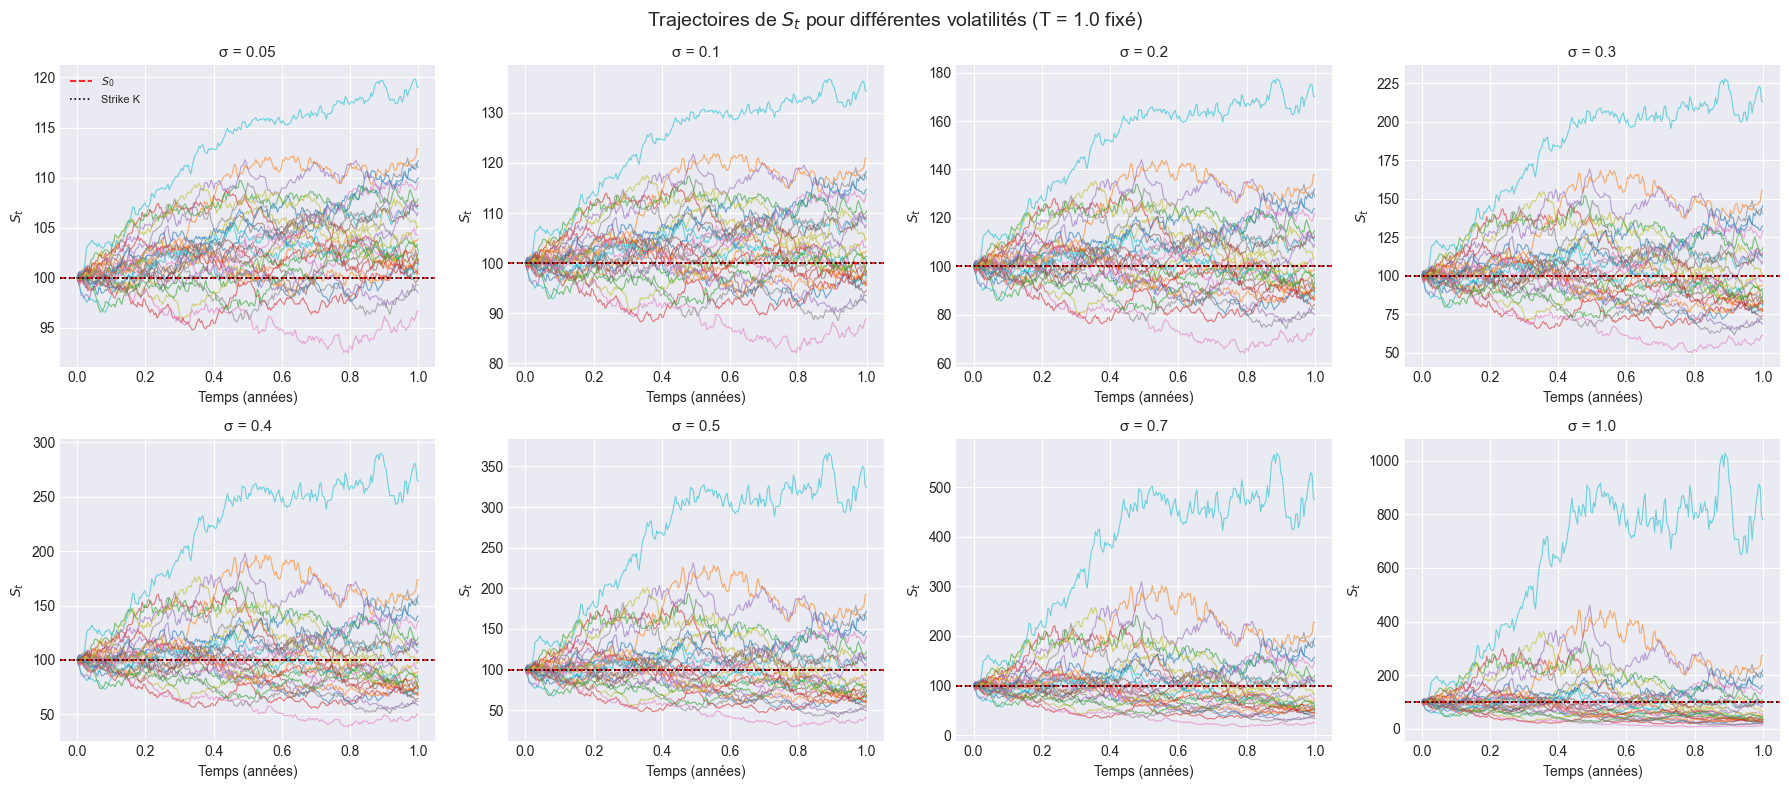

In [15]:
# Visualisation des trajectoires de S_T pour différentes volatilités
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Trajectoires de $S_t$ pour différentes volatilités (T = 1.0 fixé)", fontsize=14)

volatilites_viz = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 1.0]
nb_traj_viz = 30
n = 252

for idx, sigma in enumerate(volatilites_viz):
    ax = axes[idx // 4, idx % 4]
    t, W = brownien(T_fixe, n, nb_trajectoires=nb_traj_viz, seed=42)
    S = S0 * np.exp((r - 0.5 * sigma**2) * t[:, np.newaxis] + sigma * W)

    for i in range(nb_traj_viz):
        ax.plot(t, S[:, i], linewidth=0.8, alpha=0.6)

    ax.axhline(y=S0, color='red', linestyle='--', linewidth=1.2, label='$S_0$')
    ax.axhline(y=K, color='black', linestyle=':', linewidth=1.2, label='Strike K')
    ax.set_title(f"σ = {sigma}", fontsize=11)
    ax.set_xlabel("Temps (années)")
    ax.set_ylabel("$S_t$")
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

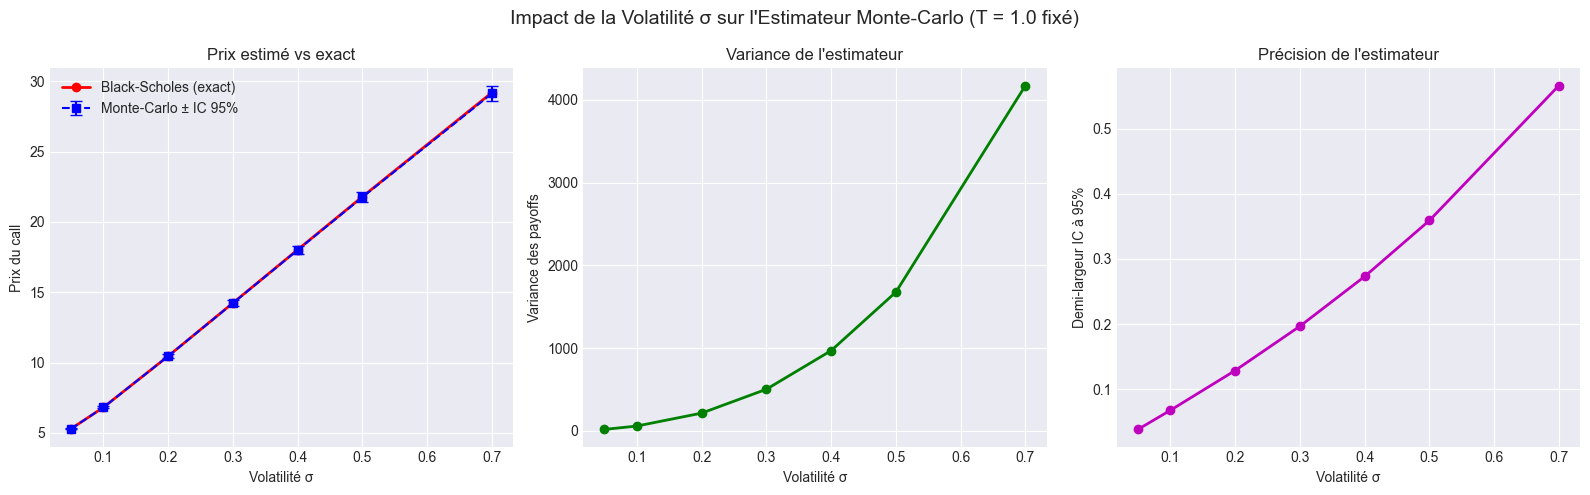

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact de la Volatilité σ sur l'Estimateur Monte-Carlo (T = 1.0 fixé)", fontsize=14)

sig_vals   = resultats_sigma[:, 0]
prix_mc    = resultats_sigma[:, 1]
variances  = resultats_sigma[:, 2]
ic_vals    = resultats_sigma[:, 3]
prix_bs    = resultats_sigma[:, 4]

# --- Graphe 1 : Prix MC vs BS ---
axes[0].plot(sig_vals, prix_bs, 'r-o', label='Black-Scholes (exact)', linewidth=2)
axes[0].errorbar(sig_vals, prix_mc, yerr=ic_vals, fmt='b--s',
                 label='Monte-Carlo ± IC 95%', linewidth=1.5, capsize=4)
axes[0].set_xlabel('Volatilité σ')
axes[0].set_ylabel('Prix du call')
axes[0].set_title('Prix estimé vs exact')
axes[0].legend()

# --- Graphe 2 : Variance ---
axes[1].plot(sig_vals, variances, 'g-o', linewidth=2)
axes[1].set_xlabel('Volatilité σ')
axes[1].set_ylabel('Variance des payoffs')
axes[1].set_title('Variance de l\'estimateur')

# --- Graphe 3 : Largeur IC ---
axes[2].plot(sig_vals, ic_vals, 'm-o', linewidth=2)
axes[2].set_xlabel('Volatilité σ')
axes[2].set_ylabel('Demi-largeur IC à 95%')
axes[2].set_title('Précision de l\'estimateur')

plt.tight_layout()
plt.show()

**Observation :** Une volatilité plus élevée amplifie la dispersion des valeurs finales $S_T$, ce qui gonfle la variance du payoff. L'IC s'élargit : il faut beaucoup plus de simulations pour atteindre la même précision.

---
## Partie 3 — Analyse jointe (T, σ) : Heatmap de la variance

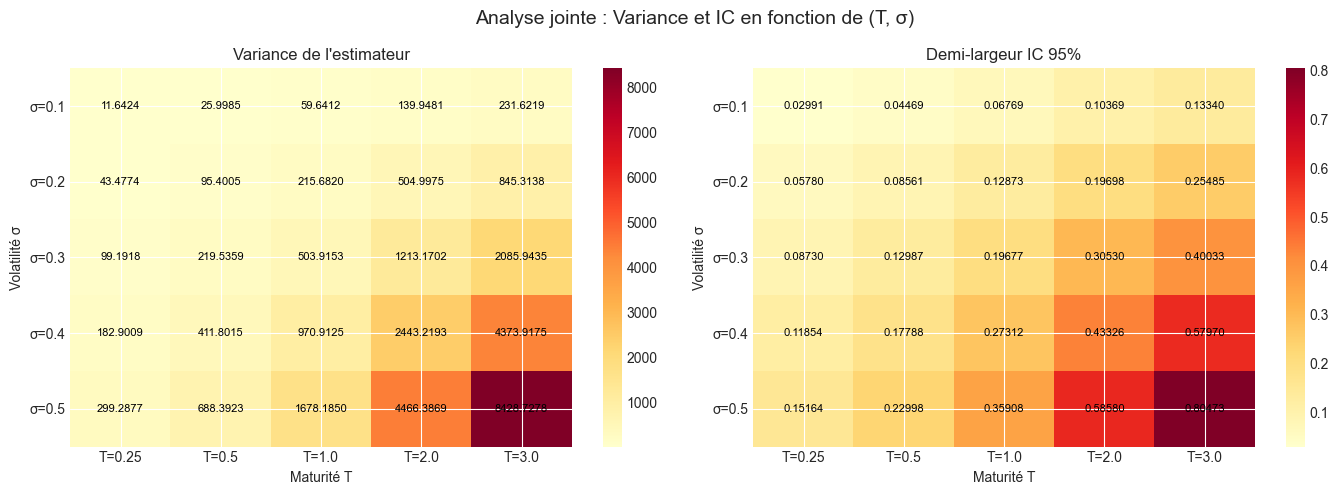

In [9]:
T_grid     = np.array([0.25, 0.5, 1.0, 2.0, 3.0])
sigma_grid = np.array([0.10, 0.20, 0.30, 0.40, 0.50])

heatmap_var = np.zeros((len(sigma_grid), len(T_grid)))
heatmap_ic  = np.zeros((len(sigma_grid), len(T_grid)))

for i, sigma in enumerate(sigma_grid):
    for j, T in enumerate(T_grid):
        _, var, ic = monte_carlo_call(S0, K, r, sigma, T, N=N, seed=42)
        heatmap_var[i, j] = var
        heatmap_ic[i, j]  = ic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse jointe : Variance et IC en fonction de (T, σ)", fontsize=14)

for ax, data, title, fmt in zip(
    axes,
    [heatmap_var, heatmap_ic],
    ["Variance de l'estimateur", "Demi-largeur IC 95%"],
    [".4f", ".5f"]
):
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(T_grid)))
    ax.set_xticklabels([f"T={t}" for t in T_grid])
    ax.set_yticks(range(len(sigma_grid)))
    ax.set_yticklabels([f"σ={s}" for s in sigma_grid])
    ax.set_xlabel('Maturité T')
    ax.set_ylabel('Volatilité σ')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(len(sigma_grid)):
        for j in range(len(T_grid)):
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

---
## Partie 4 — Combien de simulations faut-il pour maintenir la précision ?

In [16]:
IC_cible = 0.05  # on veut un IC de ±0.05

print(f"Objectif : IC à 95% de ±{IC_cible}")
print()
print("--- Impact de T (σ = 0.2 fixé) ---")
print(f"{'T':>6}  {'Variance':>12}  {'N requis':>12}")
print("-" * 36)

sigma_ref = 0.2
for T in maturites:
    _, var, _ = monte_carlo_call(S0, K, r, sigma_ref, T, N=100000, seed=42)
    N_requis = int(np.ceil((1.96**2 * var) / IC_cible**2))
    print(f"{T:>6.2f}  {var:>12.6f}  {N_requis:>12,}")

print()
print("--- Impact de σ (T = 1.0 fixé) ---")
print(f"{'σ':>6}  {'Variance':>12}  {'N requis':>12}")
print("-" * 36)

T_ref = 1.0
for sigma in volatilites:
    _, var, _ = monte_carlo_call(S0, K, r, sigma, T_ref, N=100000, seed=42)
    N_requis = int(np.ceil((1.96**2 * var) / IC_cible**2))
    print(f"{sigma:>6.2f}  {var:>12.6f}  {N_requis:>12,}")

Objectif : IC à 95% de ±0.05

--- Impact de T (σ = 0.2 fixé) ---
     T      Variance      N requis
------------------------------------
  0.10     16.036394        24,643
  0.25     43.729451        67,197
  0.50     95.975704       147,481
  1.00    217.056351       333,538
  2.00    508.478109       781,348
  3.00    851.512926     1,308,469
  5.00   1661.403995     2,552,980

--- Impact de σ (T = 1.0 fixé) ---
     σ      Variance      N requis
------------------------------------
  0.05     19.249061        29,579
  0.10     59.938732        92,105
  0.20    217.056351       333,538
  0.30    507.747029       780,225
  0.40    979.524854     1,505,178
  0.50   1694.979425     2,604,574
  0.70   4220.384387     6,485,212


---
## Conclusion

Ces expériences montrent que T et σ dégradent tous les deux la précision de l'estimateur Monte-Carlo en augmentant la variance des payoffs simulés. Maintenir une précision fixée coûte de plus en plus cher en nombre de simulations,
ce qui motive directement l'utilisation des **techniques de réduction de variance** comme les polynômes d'Hermite.